# Job Application Shortlisting

## Problem Description
A company receives many job applications and wants to predict whether a candidate
will be **Shortlisted (1)** or **Not Shortlisted (0)** from CGPA, experience, skill score,
number of projects and interview score.

**Four models:**
Logistic Regression, Random Forest, Decision Tree and K-Nearest Neighbors (KNN).




In [34]:
# Basic libraries for data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Splitting and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Four models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)

# Fixed random seed so results are reproducible
RANDOM_STATE = 42

## 2. Synthetic Dataset

**How the data is generated**
1. 1500 applicants are created with random values for each feature.
2. A **hidden hiring score** is calculated from the features (weighted sum) plus random noise.
3. Two penalty rules are applied to the hidden score:
   - Interview score below 40 - subtract 12 points
   - CGPA below 2.5 - subtract 10 points
4. The **top 38%** of hiring scores become `shortlisted = 1`, the rest become 0.
5. The hidden score is **not kept** in the dataset (keeping it would be data leakage).

**Features**

| Feature | Meaning | Range |
|---|---|---|
| `cgpa` | Academic result | 2.0 – 4.0 |
| `experience` | Years of work experience | 0 – 10 |
| `skill_score` | Technical skill test score | 0 – 100 |
| `projects` | Number of completed projects | 0 – 10 |
| `interview_score` | Interview performance | 0 – 100 |
| `shortlisted` | **Target** (1 = shortlisted, 0 = not) | 0 / 1 |

In [35]:
rng = np.random.default_rng(RANDOM_STATE)  # random number generated with a fixed seed
n_samples = 1500                           # number of candidates

# Five input features.
cgpa = np.clip(rng.normal(3.0, 0.5, n_samples), 2.0, 4.0).round(2)
experience = np.clip(rng.poisson(3, n_samples), 0, 10)
skill_score = np.clip(rng.normal(65, 15, n_samples), 0, 100).round(1)
projects = np.clip(rng.poisson(3, n_samples), 0, 10)
interview_score = np.clip(rng.normal(60, 18, n_samples), 0, 100).round(1)

# Calculate Hidden hiring score
hiring_score = (
    0.25 * (cgpa / 4 * 100) +
    0.15 * (experience / 10 * 100) +
    0.25 * skill_score +
    0.10 * (projects / 10 * 100) +
    0.25 * interview_score
)

# Add random noise to represent human judgement.
hiring_score = hiring_score + rng.normal(0, 4, n_samples)

# Rules: Penalties -> very poor interview score or low CGPA
hiring_score = np.where(interview_score < 40, hiring_score - 12, hiring_score)
hiring_score = np.where(cgpa < 2.5, hiring_score - 10, hiring_score)

# The top 38% of hiring scores become Shortlisted = 1.
cutoff = np.percentile(hiring_score, 62)
shortlisted = (hiring_score >= cutoff).astype(int)

# DataFrame
df = pd.DataFrame({
    "cgpa": cgpa,
    "experience": experience,
    "skill_score": skill_score,
    "projects": projects,
    "interview_score": interview_score,
    "shortlisted": shortlisted
})

df.head()

,cgpa,experience,skill_score,projects,interview_score,shortlisted
0,3.15,3,61.2,1,93.9,0
1,2.48,2,53.9,3,92.1,0
2,3.38,3,82.3,6,45.7,1
3,3.47,2,50.8,3,83.0,1
4,2.02,5,58.3,0,61.1,0


## 4. Exploratory Data Analysis
Here checked the size of the data, missing values, summary statistics, class balance,
and how each feature differs between shortlisted and not shortlisted candidates.

In [36]:
print("Dataset shape:", df.shape)

print("\nMissing values:\n", df.isnull().sum())

# Print summary statistics.
print("\nSummary statistics:")
display(df.describe().round(2))

# Class distribution (counts and percentages)
print("\nClass distribution:")
print(df["shortlisted"].value_counts())
print("\nClass percentage:")
print((df["shortlisted"].value_counts(normalize=True) * 100).round(1))

print("\nAverage feature values for each class:")
display(df.groupby("shortlisted").mean().round(2))

Dataset shape: (1500, 6)

Missing values:
 cgpa               0
experience         0
skill_score        0
projects           0
interview_score    0
shortlisted        0
dtype: int64

Summary statistics:


,cgpa,experience,skill_score,projects,interview_score,shortlisted
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,2.99,2.95,64.58,3.04,59.84,0.38
std,0.48,1.74,14.59,1.77,17.70,0.49
min,2.00,0.00,12.10,0.00,4.10,0.00
25%,2.66,2.00,55.20,2.00,47.70,0.00
50%,3.00,3.00,64.60,3.00,59.55,0.00
75%,3.31,4.00,74.43,4.00,72.40,1.00
max,4.00,9.00,100.00,10.00,100.00,1.00



Class distribution:
shortlisted
0    930
1    570
Name: count, dtype: int64

Class percentage:
shortlisted
0    62.0
1    38.0
Name: proportion, dtype: float64

Average feature values for each class:


,cgpa,experience,skill_score,projects,interview_score
shortlisted,,,,,
0,2.86,2.62,61.36,2.89,53.74
1,3.20,3.47,69.84,3.30,69.80


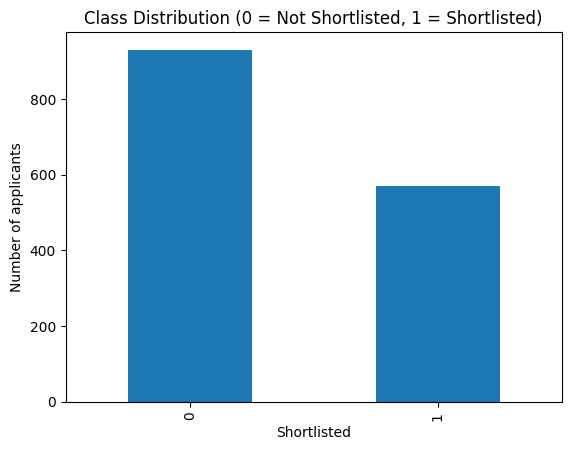

In [37]:
# Plot the class distribution.
df["shortlisted"].value_counts().plot(kind="bar")
plt.title("Class Distribution (0 = Not Shortlisted, 1 = Shortlisted)")
plt.xlabel("Shortlisted")
plt.ylabel("Number of applicants")
plt.show()

### Observations
- There are no missing values and all features are numeric, so **no encoding is needed**.
- The classes are mildly imbalanced (about 62% Not Shortlisted and 38% Shortlisted).
- Shortlisted applicants have higher average CGPA, skill score and interview score.

## 4. Data Preprocessing and Train-Test Split

**Steps and justification**
1. **Stratified 80% / 20% train-test split.** Stratify keeps the same 38% shortlist rate in both sets.
2. **Feature scaling (StandardScaler)** for Logistic Regression and KNN. KNN uses distances, so a large-range feature like `skill_score` (0–100) would dominate `cgpa` (2–4). The scaler is fitted **only on training data** to avoid leakage. Decision Tree and Random Forest do not need scaling.
3. **Class imbalance** is mild, so no resampling is used. Instead we use `class_weight="balanced"` for the models that support it.

In [38]:
# Separate features and target
X = df.drop("shortlisted", axis=1)
y = df["shortlisted"]

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

# Create the scaler and fit it only on the training data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the test data.
X_test_scaled = scaler.transform(X_test)

Training set size: 1200
Test set size: 300


## 5. Model 1: Logistic Regression

**Idea:** It calculates a weighted sum of the features and converts it into a probability between 0 and 1. Probability above 0.5 - Shortlisted.

**Parameters**
- `max_iter=1000`: enough iterations to converge.
- `class_weight="balanced"`: handles the class imbalance.
- Uses **scaled** data.

In [39]:
# Create the Logistic Regression model.
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# Train the model using the scaled training data.
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## 6. Model 2: Random Forest

**Idea:** It builds many decision trees on slightly different samples of the data and combines their votes. This reduces overfitting.

**Parameters**
- `n_estimators=100`: 100 trees.
- `max_depth=8`: limits the depth of each tree.
- `class_weight="balanced"`: handles the class imbalance.
- Uses **unscaled** data.

In [40]:
# Create the Random Forest model.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# Train the model using the training data.
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, random_state=42)

## 7. Model 3: Decision Tree

**Idea:** A single tree that asks yes/no questions such as "Is interview score < 40?". It is easy to understand, but it can overfit if it grows too deep.

**Parameters**
- `max_depth=5`: keeps the tree small.
- `class_weight="balanced"`: handles the class imbalance.
- Uses **unscaled** data.

In [41]:
# Create the Decision Tree model.
dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# Train the model using the training data.
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

## 8. Model 4: K-Nearest Neighbors (KNN)

**Idea:** To classify an applicant, KNN finds the `k` most similar applicants in the training data and takes a majority vote.

**Parameters**
- `n_neighbors=5`: look at the 5 nearest applicants.
- Uses **scaled** data (distance-based model).

In [42]:
# Create the KNN model.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using the scaled training data.
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

## 9. Evaluation Results

All four models are evaluated on the **same test set** using:
- **Accuracy:** overall correct predictions.
- **Precision:** of the applicants predicted as shortlisted, how many truly were? (low precision = many false positives)
- **Recall:** of the truly shortlisted applicants, how many did we find? (low recall = many false negatives)
- **F1-score:** balance of precision and recall.
- **Confusion matrix:** shows TN, FP, FN, TP.

In [43]:
def evaluate_model(model_name, model, X_train_data, X_test_data):

    y_pred = model.predict(X_test_data)

    # Calculate training accuracy
    train_accuracy = accuracy_score(y_train, model.predict(X_train_data))

    # Calculate the test metrics.
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Get the confusion matrix values.
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"Model: {model_name}")
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))
    print("Confusion Matrix:\n", cm)

    # Confusion matrix.
    ConfusionMatrixDisplay(cm, display_labels=["Not Shortlisted", "Shortlisted"]).plot(cmap="Blues")
    plt.title(model_name)
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "False Positives": fp,
        "False Negatives": fn,
        "Train Accuracy": train_accuracy
    }

Model: Logistic Regression
Accuracy: 0.8567
Precision: 0.763
Recall: 0.9035
F1-score: 0.8273
Confusion Matrix:
 [[154  32]
 [ 11 103]]


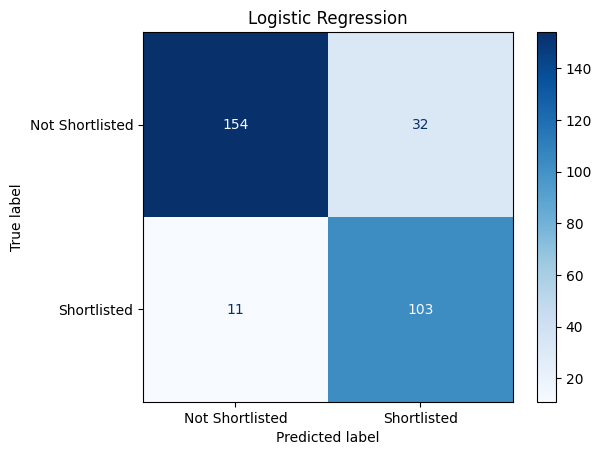

Model: Random Forest
Accuracy: 0.8267
Precision: 0.7422
Recall: 0.8333
F1-score: 0.7851
Confusion Matrix:
 [[153  33]
 [ 19  95]]


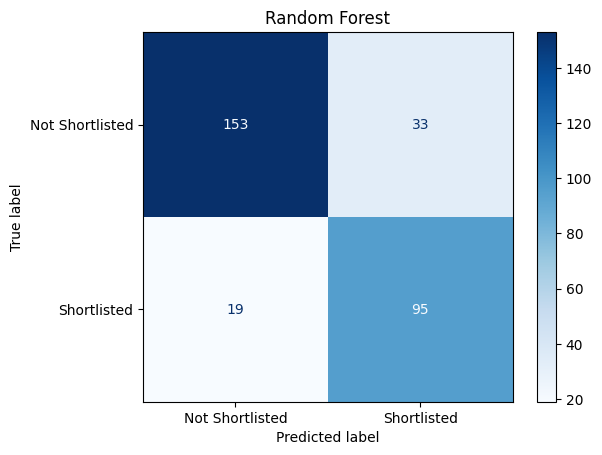

Model: Decision Tree
Accuracy: 0.7833
Precision: 0.6788
Recall: 0.8158
F1-score: 0.741
Confusion Matrix:
 [[142  44]
 [ 21  93]]


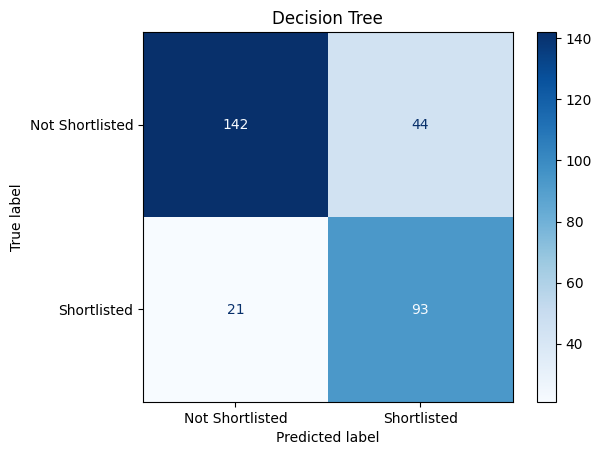

Model: KNN
Accuracy: 0.8333
Precision: 0.7623
Recall: 0.8158
F1-score: 0.7881
Confusion Matrix:
 [[157  29]
 [ 21  93]]


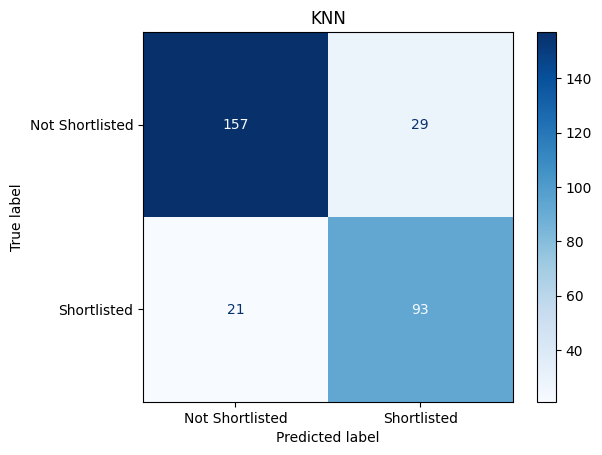

In [44]:
# Evaluation all four models
results = []
results.append(evaluate_model("Logistic Regression", lr_model, X_train_scaled, X_test_scaled))
results.append(evaluate_model("Random Forest", rf_model, X_train, X_test))
results.append(evaluate_model("Decision Tree", dt_model, X_train, X_test))
results.append(evaluate_model("KNN", knn_model, X_train_scaled, X_test_scaled))

- **ROC curve / AUC:** shows how well the model separates shortlisted from not-shortlisted applicants at all thresholds. A curve closer to the top-left corner (AUC closer to 1) is better. The dashed diagonal line is random guessing (AUC = 0.5).

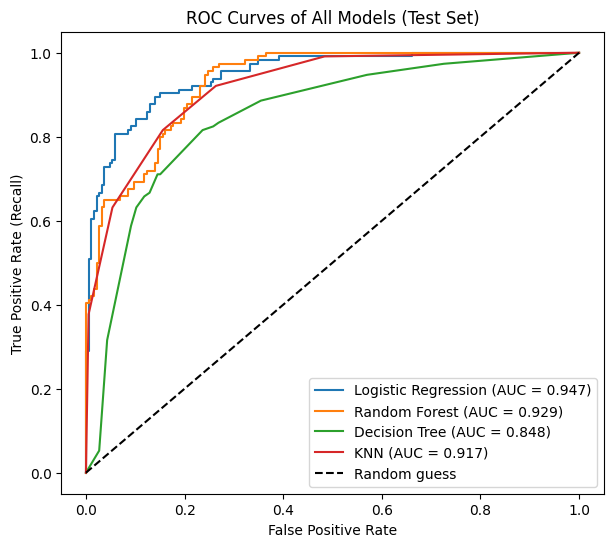

In [45]:
# Plot the ROC curves of all four models on one graph.
plt.figure(figsize=(7, 6))
models_for_roc = [
    ("Logistic Regression", lr_model, X_test_scaled),
    ("Random Forest", rf_model, X_test),
    ("Decision Tree", dt_model, X_test),
    ("KNN", knn_model, X_test_scaled)
]

for model_name, model, X_test_data in models_for_roc:
    y_prob = model.predict_proba(X_test_data)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves of All Models (Test Set)")
plt.legend()
plt.show()

## 11. Model Comparison
The table below compare the models side by side.
The **gap between train and test accuracy** is an indicator of overfitting.

In [46]:
# All results into one table.
comparison = pd.DataFrame(results).set_index("Model")

# Overfitting check
comparison["Overfit Gap"] = comparison["Train Accuracy"] - comparison["Accuracy"]

# Comparison table.
comparison.round(4)

,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,Train Accuracy,Overfit Gap
Model,,,,,,,,
Logistic Regression,0.8567,0.7630,0.9035,0.8273,32,11,0.8250,-0.0317
Random Forest,0.8267,0.7422,0.8333,0.7851,33,19,0.9508,0.1242
Decision Tree,0.7833,0.6788,0.8158,0.7410,44,21,0.8400,0.0567
KNN,0.8333,0.7623,0.8158,0.7881,29,21,0.8950,0.0617


## 11. Discussion, Justification and Conclusion


### **Comparison**

- **Logistic Regression performed best.** It has the highest Accuracy (0.857), Precision (0.763), Recall (0.904) and F1-score (0.827).

- **False negatives:** Logistic Regression missed only 11, compared with 19 for Random Forest and 21 each for Decision Tree and KNN. In hiring, missing good applicants is costly, so this matters.

- **False positives:** KNN had the fewest (29), Logistic Regression was close (32), and Decision Tree had the most (44).

- **Overfitting:** Random Forest overfitted the training data (train accuracy 0.95, test accuracy 0.83). It performed worse on the test set.

- **ROC curves:** the model with the highest AUC separates the two classes best.

### **Why the models behave differently**

- The hidden hiring score was mostly a weighted sum of the features, which is a linear pattern. Logistic Regression is good at learning linear patterns, so it performed well. Random Forest and Decision Tree can learn complex rules, but the random noise in the data caused them to overfit. KNN is sensitive to noise, so it did not perform as well.


### **Conclusion**

- **Logistic Regression is the most suitable model** for this dataset. It has the best scores, the fewest false negatives, no overfitting, and it is simple to explain to HR.

- **Limitation:** the test set has only 300 applicants, so results may change slightly with a different random seed or more data.